<a href="https://colab.research.google.com/github/dikshaabrhol786/assignment-01-BITSOM_BA_2511124/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers seaborn

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
sentences = [
# Cricket
"Virat Kohli scored a brilliant century in the match",
"The bowler delivered a fast yorker to dismiss the batsman",
"T20 cricket is known for aggressive batting and quick scoring",

# Cooking
"Cooking pasta requires boiling water and adding salt",
"Baking a cake needs precise measurements of ingredients",
"Spices like turmeric and cumin enhance the flavor of food",

# Cybersecurity
"Cybersecurity protects systems from malicious attacks",
"Phishing emails try to steal personal information",
"Encryption secures sensitive communication over the internet",
"Firewalls help block unauthorized access to networks"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)
print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [ ]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)
df

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.421543,0.418328,0.001327,0.127875,0.035962,0.094342,0.029026,0.114124,0.003889
1,0.421543,1.000000,0.482789,-0.021260,0.017279,0.037228,0.008078,0.011628,0.024076,0.031572
2,0.418328,0.482789,1.000000,-0.053705,0.015115,0.068696,0.068225,-0.004205,0.048803,0.015672
3,0.001327,-0.021260,-0.053705,1.000000,0.093518,0.052679,-0.013302,0.006254,0.061794,0.121087
4,0.127875,0.017279,0.015115,0.093518,1.000000,0.123943,0.000298,0.055418,0.024511,-0.035258
5,0.035962,0.037228,0.068696,0.052679,0.123943,1.000000,0.054976,-0.017872,0.018136,0.036715
6,0.094342,0.008078,0.068225,-0.013302,0.000298,0.054976,1.000000,0.350525,0.366284,0.372516
7,0.029026,0.011628,-0.004205,0.006254,0.055418,-0.017872,0.350525,1.000000,0.304495,0.173268
8,0.114124,0.024076,0.048803,0.061794,0.024511,0.018136,0.366284,0.304495,1.000000,0.227326
9,0.003889,0.031572,0.015672,0.121087,-0.035258,0.036715,0.372516,0.173268,0.227326,1.000000


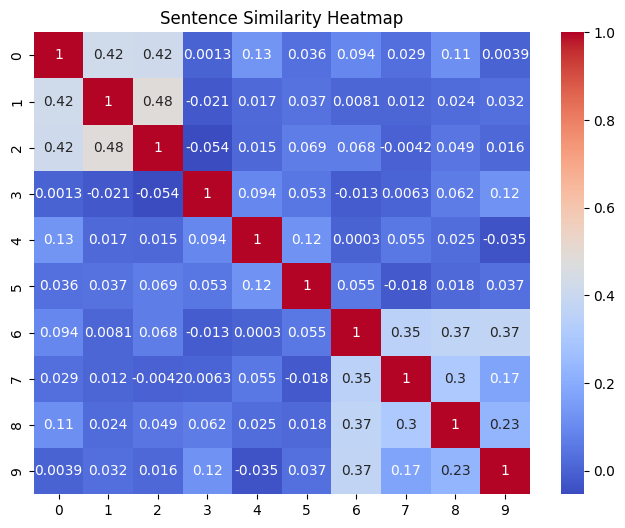

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, similarities))

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print("Top 2 Most Similar Sentences:\n")

for sentence, score in sorted_results[:2]:
    print(sentence)
    print("Similarity Score:", score)
    print()

Top 2 Most Similar Sentences:

The bowler delivered a fast yorker to dismiss the batsman
Similarity Score: 0.5822266

Virat Kohli scored a brilliant century in the match
Similarity Score: 0.44090658

